In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../datasets/greengrid_v2_2/raw_data/"

In [2]:
def cat_clean(data: pd.DataFrame):
    """Cleaning inconsistency in categorical data"""
    columns = list(data.columns)
    for column in columns:
        if data[column].dtypes == "object":
           data[column] = [i.upper().strip() for i in data[column].astype(str)]

In [ ]:
def timestamp_reg(data: pd.DataFrame, column: str):
    """Clean the timestamp formatting"""
    for row in range(len(data[column])):
        datetime = data[column][row]
        if len(datetime) != 19:
            datetime += ":00"
            date = datetime.split(" ")[0]
            time = datetime.split(" ")[1]
            if "/" in date:
                case1 = date.split("/")
                if len(case1[0]) == 2:
                    day = case1[0]
                    month = case1[1]
                    year = case1[2]
                    date = f"{year}-{month}-{day}"
                    datetime = f"{date} {time}"
                else:
                    day = case1[2]
                    month = case1[1]
                    year = case1[0]
                    date = f"{year}-{month}-{day}"
                    datetime = f"{date} {time}"
            elif "-" in date:
                case2 = date.split("-")
                day = case2[1]
                month = case2[0]
                year = case2[2]
                date = f"{year}-{month}-{day}"
                datetime = f"{date} {time}"
            data.loc[row, column] = datetime

In [14]:
def cat_flag(data: pd.DataFrame):
    """Flagging inconsistency in categorical data"""
    columns = list(data.columns)
    for column in columns:
        if data[column].dtypes == "object":
            a = list(
                    set(
                        [i.upper().strip() for i in list(data[column].unique().astype(str))]
                        )
                )
            b = list(data[column].unique())
            if len(a) == len(b):
                print(column, "->", "Consistent")
            else:
                print(column, "->", "Inconsistent")

In [34]:
def timestamp_flag(data: pd.Series):
    """Flag the timestamp formatting"""
    case1 = []
    case2 = []
    case3 = []
    for i in range(len(data)):
        datetime = data[i]
        if len(datetime) != 19:
            date = datetime.split(" ")[0]
            if "/" in date:
                if len(date.split("/")[0]) == 2:
                    case1.append(datetime)
                else:
                    case2.append(datetime)
            elif "-" in date:
                case3.append(datetime)
    print(f"There are {len(case1)} rows that has format: %d/%m/%Y %H:%M")
    print(f"There are {len(case2)} rows that has format: %Y/%m/%d %H:%M")
    print(f"There are {len(case3)} rows that has format: %m-%d-%Y %H:%M")

## Asset

In [7]:
assets = path + "asset_registry_raw.csv"

df_assets = pd.read_csv(assets)

df_assets

,asset_id,asset_name,technology,region,grid_node,capacity_mw,commission_date,asset_status,source_system
0,SOL-N01,North Solar One,Solar PV,North,NORTH_A,180,2023-06-01,Operational,ASSET_REGISTRY
1,SOL-N02,North Solar Two,Solar PV,North,NORTH_A,140,2024-03-15,Operational,ASSET_REGISTRY
2,WND-N01,North Wind One,WIND,North,NORTH_B,220,2022-10-01,Operational,ASSET_REGISTRY
3,SOL-C01,Central Solar One,Solar PV,Central,CENTRAL_A,160,2023-01-10,Operational,ASSET_REGISTRY
4,SOL-C02,Central Solar Two,Solar PV,Central,CENTRAL_A,110,2024-07-01,Operational,ASSET_REGISTRY
5,WND-C01,Central Wind One,wind,central,CENTRAL_B,180,2022-05-20,Operational,ASSET_REGISTRY


In [8]:
cat_clean(df_assets)
cat_flag(df_assets)

asset_id -> Consistent
asset_name -> Consistent
technology -> Consistent
region -> Consistent
grid_node -> Consistent
commission_date -> Consistent
asset_status -> Consistent
source_system -> Consistent


In [9]:
df_assets = df_assets.drop_duplicates()
df_assets.duplicated().sum()

np.int64(0)

In [10]:
df_assets = df_assets.dropna()
df_assets.isnull().sum()

asset_id           0
asset_name         0
technology         0
region             0
grid_node          0
capacity_mw        0
commission_date    0
asset_status       0
source_system      0
dtype: int64

## BESS

In [31]:
bess = path + "bess_operations_raw.csv"

df_bess = pd.read_csv(bess)

df_bess.head()

,timestamp,region,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh,source_system,record_status
0,2025-01-01 00:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID
1,2025-01-01 00:00:00,Central,50,200,0.0,0.0,BESS_CONTROLLER,VALID
2,2025-01-01 01:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID
3,2025-01-01 01:00:00,Central,50,200,0.0,0.0,BESS_CONTROLLER,VALID
4,2025-01-01 02:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID


In [32]:
timestamp_reg(df_bess, "timestamp")

In [35]:
timestamp_flag(df_bess["timestamp"])

There are 0 rows that has format: %d/%m/%Y %H:%M
There are 0 rows that has format: %Y/%m/%d %H:%M
There are 0 rows that has format: %m-%d-%Y %H:%M


In [287]:
cat_clean(df_bess)
cat_flag(df_bess)

timestamp -> Consistent
region -> Consistent
source_system -> Consistent
record_status -> Consistent


In [288]:
df_bess = df_bess.drop_duplicates()
df_bess.duplicated().sum()

np.int64(0)

In [289]:
df_bess = df_bess.dropna()
df_bess.isnull().sum()

timestamp                      0
region                         0
battery_power_capacity_mw      0
battery_energy_capacity_mwh    0
charge_mwh                     0
discharge_mwh                  0
source_system                  0
record_status                  0
dtype: int64

In [290]:
df_bess.describe()

,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17469.0,17469.0,17469.000000,17469.000000
mean,50.0,200.0,2.765242,2.212873
std,0.0,0.0,18.105486,8.571690
min,50.0,200.0,-10.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,999.000000,37.500000


In [291]:
df_bess[df_bess["charge_mwh"] >= 0][df_bess["charge_mwh"] != 999].describe()

C:\Users\User\AppData\Local\Temp\ipykernel_2184\2627907241.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_bess[df_bess["charge_mwh"] >= 0][df_bess["charge_mwh"] != 999].describe()


,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17461.0,17461.0,17461.000000,17461.000000
mean,50.0,200.0,2.539947,2.213887
std,0.0,0.0,10.024850,8.573523
min,50.0,200.0,0.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,50.000000,37.500000


Menggunakan metode **Capping**, di mana nilai negatif diganti menjadi 0 dan 999 diganti menjadi 50

In [292]:
df_bess.loc[df_bess["charge_mwh"] < 0, "charge_mwh"] = 0
df_bess.loc[df_bess["charge_mwh"] == 999, "charge_mwh"] = 50

In [293]:
df_bess.describe()

,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17469.0,17469.0,17469.000000,17469.000000
mean,50.0,200.0,2.550232,2.212873
std,0.0,0.0,10.048321,8.571690
min,50.0,200.0,0.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,50.000000,37.500000


## Dispatch

In [37]:
dispatch = path + "dispatch_curtailment_log_raw.csv"

df_dispatch = pd.read_csv(dispatch)

df_dispatch.head()

,event_id,region,start_time,end_time,reason,operator_action,source_system,record_status
0,CE-00001,North,2025-01-11 12:00:00,2025-01-11 12:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
1,CE-00002,North,2025-01-25 11:00:00,2025-01-25 13:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
2,CE-00003,North,2025-02-01 11:00:00,2025-02-01 11:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
3,CE-00004,North,2025-02-02 10:00:00,2025-02-02 10:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
4,CE-00005,North,2025-02-02 14:00:00,2025-02-02 14:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID


In [38]:
timestamp_reg(df_dispatch, "start_time")
timestamp_reg(df_dispatch, "end_time")

In [39]:
timestamp_flag(df_dispatch["start_time"])
timestamp_flag(df_dispatch["end_time"])

There are 0 rows that has format: %d/%m/%Y %H:%M
There are 0 rows that has format: %Y/%m/%d %H:%M
There are 0 rows that has format: %m-%d-%Y %H:%M
There are 0 rows that has format: %d/%m/%Y %H:%M
There are 0 rows that has format: %Y/%m/%d %H:%M
There are 0 rows that has format: %m-%d-%Y %H:%M


In [295]:
cat_clean(df_dispatch)
cat_flag(df_dispatch)

event_id -> Consistent
region -> Consistent
start_time -> Consistent
end_time -> Consistent
reason -> Consistent
operator_action -> Consistent
source_system -> Consistent
record_status -> Consistent


In [296]:
df_dispatch = df_dispatch.drop_duplicates()
df_dispatch.duplicated().sum()

np.int64(0)

In [297]:
df_dispatch = df_dispatch.dropna()
df_dispatch.isnull().sum()

event_id           0
region             0
start_time         0
end_time           0
reason             0
operator_action    0
source_system      0
record_status      0
dtype: int64

## EMS

In [40]:
ems = path + "ems_operations_raw.csv"
df_ems = pd.read_csv(ems)

df_ems.head()

,timestamp,total_demand_mwh,north_export_limit_mw,central_export_limit_mw,source_system,demand_unit,record_status
0,01/01/2025 00:00,269.595543,80.0,220.0,EMS,MWh,VALID
1,2025-01-01 01:00:00,304.452778,80.0,220.0,EMS,MWh,VALID
2,2025-01-01 02:00:00,285.878869,80.0,220.0,EMS,MWh,VALID
3,2025-01-01 03:00:00,299.750572,80.0,220.0,EMS,MWh,VALID
4,2025-01-01 04:00:00,321.041077,80.0,220.0,EMS,MWh,VALID


In [41]:
timestamp_reg(df_ems, "timestamp")

In [42]:
timestamp_flag(df_ems["timestamp"])

There are 0 rows that has format: %d/%m/%Y %H:%M
There are 0 rows that has format: %Y/%m/%d %H:%M
There are 0 rows that has format: %m-%d-%Y %H:%M


In [299]:
cat_clean(df_ems)
cat_flag(df_ems)

timestamp -> Consistent
source_system -> Consistent
demand_unit -> Consistent
record_status -> Consistent


In [300]:
df_ems.loc[df_ems["demand_unit"] == "MW", "demand_unit"] = "MWH"

In [301]:
df_ems = df_ems.drop_duplicates()
df_ems.duplicated().sum()

np.int64(0)

In [302]:
df_ems = df_ems.dropna()
df_ems.isnull().sum()

timestamp                  0
total_demand_mwh           0
north_export_limit_mw      0
central_export_limit_mw    0
source_system              0
demand_unit                0
record_status              0
dtype: int64

In [303]:
df_ems.describe()

,total_demand_mwh,north_export_limit_mw,central_export_limit_mw
count,8743.000000,8743.000000,8743.000000
mean,366.860546,77.203706,219.505799
std,64.751542,6.927570,4.798616
min,201.609089,43.200000,158.400000
25%,317.932169,80.000000,220.000000
50%,366.193765,80.000000,220.000000
75%,411.910424,80.000000,220.000000
max,551.613558,80.000000,220.000000


## Market Price

In [43]:
market_price = path + "market_price_raw.csv"
df_market_price = pd.read_csv(market_price)

df_market_price.head()

,timestamp,market_price_usd_per_mwh,source_system,record_status
0,2025-01-01 00:00:00,52.97,MARKET_FEED,VALID
1,2025-01-01 01:00:00,55.24,MARKET_FEED,VALID
2,2025-01-01 02:00:00,63.02,MARKET_FEED,VALID
3,2025-01-01 03:00:00,54.80,MARKET_FEED,VALID
4,2025-01-01 04:00:00,63.04,MARKET_FEED,VALID


In [44]:
timestamp_reg(df_market_price, "timestamp")

In [45]:
timestamp_flag(df_market_price["timestamp"])

There are 0 rows that has format: %d/%m/%Y %H:%M
There are 0 rows that has format: %Y/%m/%d %H:%M
There are 0 rows that has format: %m-%d-%Y %H:%M


In [305]:
cat_clean(df_market_price)
cat_flag(df_market_price)

timestamp -> Consistent
source_system -> Consistent
record_status -> Consistent


In [306]:
df_market_price = df_market_price.drop_duplicates()
df_market_price.duplicated().sum()

np.int64(0)

In [307]:
df_market_price = df_market_price.dropna()
df_market_price.isnull().sum()

timestamp                   0
market_price_usd_per_mwh    0
source_system               0
record_status               0
dtype: int64

In [308]:
df_market_price.describe()

,market_price_usd_per_mwh
count,8744.000000
mean,67.826852
std,11.076892
min,-14.750000
25%,61.637500
50%,68.395000
75%,75.002500
max,95.080000


In [ ]:
df_market_price[df_market_price["market_price_usd_per_mwh"] < 0]

,timestamp,market_price_usd_per_mwh,source_system,record_status
755,2025-02-01 11:00:00,-11.20,MARKET_FEED,VALID
1452,2025-03-02 12:00:00,-9.27,MARKET_FEED,VALID
1812,2025-03-17 12:00:00,-7.19,MARKET_FEED,VALID
1932,2025-03-22 12:00:00,-4.20,MARKET_FEED,VALID
2002,2025-03-25 10:00:00,-12.25,MARKET_FEED,VALID
...,...,...,...,...
7164,2025-10-26 12:00:00,-3.78,MARKET_FEED,VALID
7165,2025-10-26 13:00:00,-7.60,MARKET_FEED,VALID
7331,2025-11-02 11:00:00,-10.59,MARKET_FEED,VALID
7834,2025-11-23 10:00:00,-7.24,MARKET_FEED,VALID


In [310]:
df_market_price[df_market_price["market_price_usd_per_mwh"] >= 0].describe()

,market_price_usd_per_mwh
count,8670.000000
mean,68.468300
std,8.658146
min,42.990000
25%,61.792500
50%,68.515000
75%,75.060000
max,95.080000


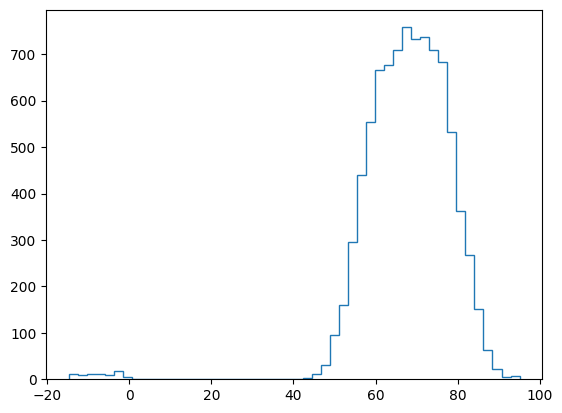

In [311]:
plt.hist(df_market_price["market_price_usd_per_mwh"], histtype="step", bins=50)
plt.show()

In [312]:
df_market_price.loc[df_market_price["market_price_usd_per_mwh"] < 0, "market_price_usd_per_mwh"] = df_market_price["market_price_usd_per_mwh"][df_market_price["market_price_usd_per_mwh"] >=0].mean()

In [313]:
df_market_price.describe()

,market_price_usd_per_mwh
count,8744.000000
mean,68.468300
std,8.621427
min,42.990000
25%,61.900000
50%,68.468300
75%,75.002500
max,95.080000


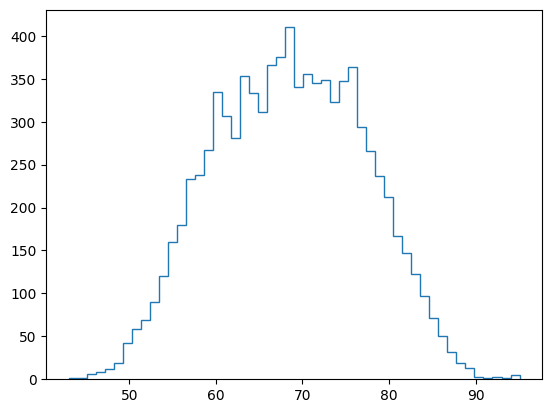

In [314]:
plt.hist(df_market_price["market_price_usd_per_mwh"], bins=50, histtype="step")
plt.show()

## SCADA

In [315]:
scada = path + "scada_generation_raw.csv"

df_scada = pd.read_csv(scada)

df_scada.head()

,timestamp,asset_id,capacity_mw,availability_pct,source_system,reading_status
0,2025-01-01 00:00:00,SOL-N01,180,98.954049,SCADA,VALID
1,2025-01-01 01:00:00,SOL-N01,180,98.271865,SCADA,VALID
2,2025-01-01 02:00:00,SOL-N01,180,99.840617,SCADA,VALID
3,2025-01-01 03:00:00,SOL-N01,180,99.483940,SCADA,VALID
4,2025-01-01 04:00:00,SOL-N01,180,98.098109,SCADA,VALID


In [316]:
cat_clean(df_scada)
cat_flag(df_scada)

timestamp -> Consistent
asset_id -> Consistent
source_system -> Consistent
reading_status -> Consistent


In [317]:
df_scada = df_scada.drop_duplicates()
df_scada.duplicated().sum()

np.int64(0)

In [318]:
df_scada = df_scada.dropna()
df_scada.isnull().sum()

timestamp           0
asset_id            0
capacity_mw         0
availability_pct    0
source_system       0
reading_status      0
dtype: int64

In [319]:
df_scada.describe()

,capacity_mw,availability_pct
count,52457.000000,52457.000000
mean,164.996855,97.868654
std,34.519741,7.026568
min,110.000000,-5.000000
25%,140.000000,97.938199
50%,160.000000,98.480330
75%,180.000000,99.029906
max,220.000000,150.000000


In [320]:
df_scada[df_scada["availability_pct"] < 0]

,timestamp,asset_id,capacity_mw,availability_pct,source_system,reading_status
24220,2025-10-07 04:00:00,WND-N01,220,-5.0,SCADA,VALID
36790,2025-03-14 22:00:00,SOL-C02,110,-5.0,SCADA,VALID
50316,2025-09-29 12:00:00,WND-C01,180,-5.0,SCADA,VALID


In [321]:
df_scada[df_scada["availability_pct"] > 100]

,timestamp,asset_id,capacity_mw,availability_pct,source_system,reading_status
2847,2025-04-29 15:00:00,SOL-N01,180,150.0,SCADA,VALID
11900,2025-05-11 20:00:00,SOL-N02,140,150.0,SCADA,VALID
50008,2025-09-16 16:00:00,WND-C01,180,150.0,SCADA,VALID


In [322]:
df_scada.loc[df_scada["availability_pct"] < 0, "availability_pct"] = 0
df_scada.loc[df_scada["availability_pct"] > 100, "availability_pct"] = 100

In [323]:
df_scada.describe()

,capacity_mw,availability_pct
count,52457.000000,52457.000000
mean,164.996855,97.866080
std,34.519741,7.011425
min,110.000000,0.000000
25%,140.000000,97.938199
50%,160.000000,98.480330
75%,180.000000,99.029906
max,220.000000,100.000000


## Weather

In [324]:
weather = path + "weather_station_raw.csv"
df_weather = pd.read_csv(weather)

df_weather.head()

,timestamp,station_id,solar_irradiance_index,wind_speed_mps,temperature_c,source_system,record_status
0,2025-01-01 00:00:00,WX-MASTER,0.0,8.795,28.11,WEATHER_STATION,VALID
1,2025-01-01 01:00:00,WX-MASTER,0.0,6.695,27.40,WEATHER_STATION,VALID
2,2025-01-01 02:00:00,WX-MASTER,0.0,7.087,25.98,WEATHER_STATION,VALID
3,2025-01-01 03:00:00,WX-MASTER,0.0,6.664,24.87,WEATHER_STATION,VALID
4,2025-01-01 04:00:00,WX-MASTER,0.0,7.283,24.71,WEATHER_STATION,VALID


In [325]:
cat_clean(df_weather)
cat_flag(df_weather)

timestamp -> Consistent
station_id -> Consistent
source_system -> Consistent
record_status -> Consistent


In [326]:
df_weather = df_weather.drop_duplicates()
df_weather.duplicated().sum()

np.int64(0)

In [327]:
df_weather = df_weather.dropna()
df_weather.isnull().sum()

timestamp                 0
station_id                0
solar_irradiance_index    0
wind_speed_mps            0
temperature_c             0
source_system             0
record_status             0
dtype: int64

In [328]:
df_weather.describe()

,solar_irradiance_index,wind_speed_mps,temperature_c
count,8725.000000,8725.000000,8725.000000
mean,0.276012,7.026388,26.973339
std,0.337534,2.001479,3.032949
min,0.000000,-2.000000,17.740000
25%,0.000000,5.816000,24.650000
50%,0.000000,7.012000,26.970000
75%,0.602900,8.206000,29.260000
max,1.049000,60.000000,35.580000


In [329]:
df_weather[df_weather["wind_speed_mps"] < 0]

,timestamp,station_id,solar_irradiance_index,wind_speed_mps,temperature_c,source_system,record_status
4301,2025-06-29 05:00:00,WX-MASTER,0.0,-2.0,24.53,WEATHER_STATION,VALID
4943,2025-07-25 23:00:00,WX-MASTER,0.0,-2.0,25.90,WEATHER_STATION,VALID
8035,2025-12-01 19:00:00,WX-MASTER,0.0,-2.0,28.78,WEATHER_STATION,VALID


In [330]:
df_weather.loc[df_weather["wind_speed_mps"] < 0, "wind_speed_mps"] = 0

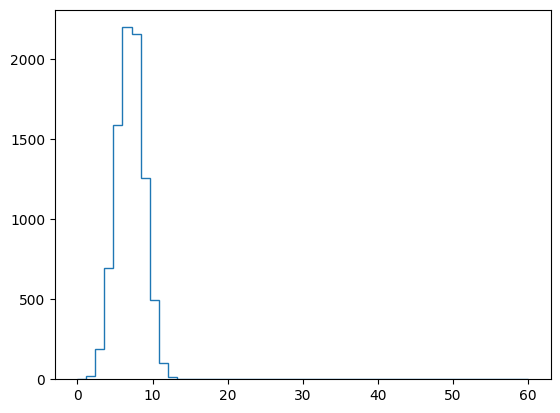

In [331]:
plt.hist(df_weather["wind_speed_mps"], histtype="step", bins=50)
plt.show()

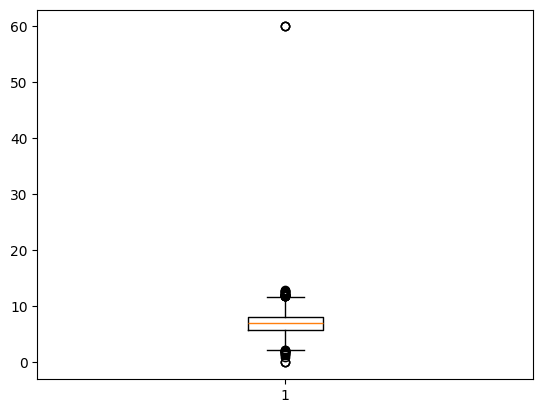

In [332]:
plt.boxplot(df_weather["wind_speed_mps"])
plt.show()

In [333]:
df_weather.loc[df_weather["wind_speed_mps"] == 60, "wind_speed_mps"] = df_weather["wind_speed_mps"][df_weather["wind_speed_mps"] != 60].max()

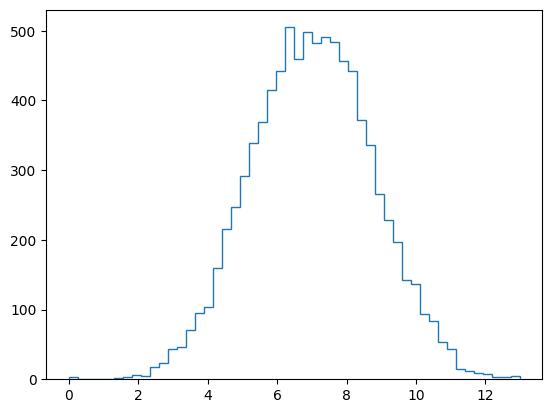

In [334]:
plt.hist(df_weather["wind_speed_mps"], histtype="step", bins=50)
plt.show()

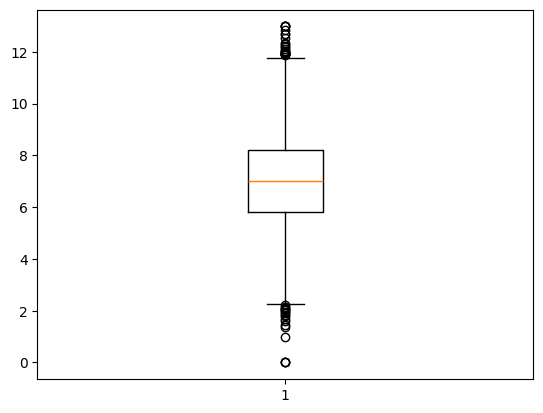

In [335]:
plt.boxplot(df_weather["wind_speed_mps"])
plt.show()

## Saving Data

In [336]:
clean_path = "../datasets/greengrid_v2_2/clean_data/"

df_assets.to_csv(clean_path + "asset_registry_clean.csv", index=False)
df_bess.to_csv(clean_path + "bess_operations_clean.csv", index=False)
df_dispatch.to_csv(clean_path + "dispatch_curtailment_log_clean.csv", index=False)
df_ems.to_csv(clean_path + "ems_operations_clean.csv", index=False)
df_market_price.to_csv(clean_path + "market_price_clean.csv", index=False)
df_scada.to_csv(clean_path + "scada_generation_clean.csv", index=False)
df_weather.to_csv(clean_path + "weather_station_clean.csv", index=False)